In [1]:
import jax

In [2]:
print("hi")

hi


In [3]:
import jax.numpy as jnp

In [15]:
import matplotlib.pyplot as plt

x_jnp = jnp.linspace(-10, 10, 2000)
y_jnp_list = [x_jnp**n for n in range(20)]
# How can I make an operator L in JAX which sends a polynomial of degree 1 to a polynomial of degree n?
# I want to do the above to "automate" the creation of an n degree polynomial for graphing
# L: x --> x**j for 0 < j <= n
# L: R --> space of polynomials of degree < n
# L is 1 column and n rows
# L should be an array of 20 one element lists
y_jnp_list

[Array([1., 1., 1., ..., 1., 1., 1.], dtype=float32),
 Array([-10.      ,  -9.989994,  -9.97999 , ...,   9.97999 ,   9.989996,
         10.      ], dtype=float32),
 Array([100.     ,  99.79998,  99.6002 , ...,  99.6002 ,  99.80002,
        100.     ], dtype=float32),
 Array([-1000.    ,  -997.0012,  -994.009 , ...,   994.009 ,   997.0018,
         1000.    ], dtype=float32),
 Array([10000.   ,  9960.036,  9920.199, ...,  9920.199,  9960.044,
        10000.   ], dtype=float32),
 Array([-100000.  ,  -99500.7 ,  -99003.49, ...,   99003.49,   99500.8 ,
         100000.  ], dtype=float32),
 Array([1.0000000e+06, 9.9401144e+05, 9.8805381e+05, ..., 9.8805381e+05,
        9.9401256e+05, 1.0000000e+06], dtype=float32),
 Array([-1.000000e+07, -9.930168e+06, -9.860767e+06, ...,  9.860767e+06,
         9.930181e+06,  1.000000e+07], dtype=float32),
 Array([1.000000e+08, 9.920232e+07, 9.841035e+07, ..., 9.841035e+07,
        9.920247e+07, 1.000000e+08], dtype=float32),
 Array([-1.0000000e+09, -9.910

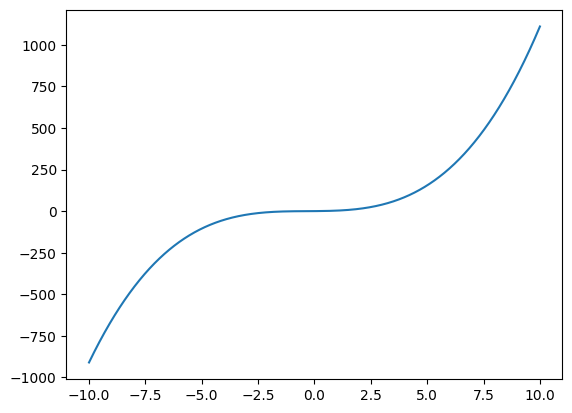

In [17]:
y_jnp = x_jnp + x_jnp**2 + x_jnp**3
plt.plot(x_jnp, y_jnp);

In [23]:
import numpy as np
import jax.numpy as jnp

x_np = np.linspace(0, 10, 1000)
x_jnp = jnp.linspace(0, 10, 1000)
for i in range(3):
    print("numpy element:", x_np[i])
    print("JAX element:", x_jnp[i])

numpy element: 0.0
JAX element: 0.0
numpy element: 0.01001001001001001
JAX element: 0.01001001
numpy element: 0.02002002002002002
JAX element: 0.02002002


In [21]:
type(x_np)

numpy.ndarray

In [22]:
type(x_jnp)

jaxlib._jax.ArrayImpl

In [25]:
# NumPy: mutable arrays
x = np.arange(10)
x

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [26]:
x[0] = 10
print(x)

[10  1  2  3  4  5  6  7  8  9]


In [27]:
%xmode minimal
# JAX: immutable arrays
x = jnp.arange(10)
x[0] = 10

Exception reporting mode: Minimal


TypeError: JAX arrays are immutable and do not support in-place item assignment. Instead of x[idx] = y, use x = x.at[idx].set(y) or another .at[] method: https://docs.jax.dev/en/latest/_autosummary/jax.numpy.ndarray.at.html

In [28]:
y = x.at[0].set(10)
print(x)
print(y)

[0 1 2 3 4 5 6 7 8 9]
[10  1  2  3  4  5  6  7  8  9]


In [31]:
import jax
import jax.numpy as jnp

x = jnp.arange(5)
x

Array([0, 1, 2, 3, 4], dtype=int32)

In [32]:
isinstance(x, jax.Array)

True

In [33]:
x.devices()

{CudaDevice(id=0)}

In [34]:
x.sharding

SingleDeviceSharding(device=CudaDevice(id=0), memory_kind=device)

In [35]:
import jax.numpy as jnp

def norm(X):
  X = X - X.mean(0)
  return X / X.std(0)

In [36]:
from jax import jit
norm_compiled = jit(norm)

In [37]:
np.random.seed(1701)
X = jnp.array(np.random.rand(10000, 10))
np.allclose(norm(X), norm_compiled(X), atol=1E-6)

True

In [38]:
%timeit norm(X).block_until_ready()
%timeit norm_compiled(X).block_until_ready()

1.48 ms ± 45.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.28 ms ± 4.07 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [39]:
def get_negatives(x):
  return x[x < 0]

x = jnp.array(np.random.randn(10))
x

Array([ 0.32324824, -0.10570311,  0.95973444, -0.59403396, -0.8680282 ,
        0.49947882,  0.51224375,  1.0338178 ,  0.719722  , -0.23489487],      dtype=float32)

In [40]:
jnp.shape(x)

(10,)

In [41]:
get_negatives(x)

Array([-0.10570311, -0.59403396, -0.8680282 , -0.23489487], dtype=float32)

In [42]:
jnp.shape(get_negatives(x))

(4,)

In [43]:
jit(get_negatives)(x)

NonConcreteBooleanIndexError: Array boolean indices must be concrete; got bool[10]

See https://docs.jax.dev/en/latest/errors.html#jax.errors.NonConcreteBooleanIndexError

In [51]:
from jax import grad

def sum_logistic(x):
  return jnp.sum(1.0 / (1.0 + jnp.exp(-x)))

x_small = jnp.arange(3.)
derivative_fn = grad(sum_logistic)
print(derivative_fn(x_small))
print("blah")

[0.25       0.19661194 0.10499357]
blah


In [62]:
def first_finite_differences(f, x, eps=1E-3):
  return jnp.array([(f(x + eps * v) - f(x - eps * v)) / (2 * eps)
                   for v in jnp.eye(len(x))])

print(first_finite_differences(sum_logistic, x_small))

[0.24998187 0.1965761  0.10502338]


In [59]:
jnp.eye(len(x_small))

Array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]], dtype=float32)

In [69]:
print(jit(grad(sum_logistic))(1.))

0.19661194


In [66]:
print(grad(jit(grad(sum_logistic)))(1.0))

-0.09085774


In [65]:
print(jit(grad(jit(grad(sum_logistic))))(1.0))

-0.09085774


In [63]:
print(grad(jit(grad(jit(grad(sum_logistic)))))(1.0))

-0.0353256


In [70]:
from jax import jacobian
print(jacobian(jnp.exp)(x_small))

[[1.        0.        0.       ]
 [0.        2.7182817 0.       ]
 [0.        0.        7.389056 ]]


In [74]:
for i in range(len(x_small)):
    print(grad(jnp.exp)(x_small[i]))

1.0
2.7182817
7.389056


In [75]:
from jax import jacfwd, jacrev
def hessian(fun):
  return jit(jacfwd(jacrev(fun)))
print(hessian(sum_logistic)(x_small))

[[-0.         -0.         -0.        ]
 [-0.         -0.09085774 -0.        ]
 [-0.         -0.         -0.07996248]]


In [80]:
def hessrev(fun):
    return jit(jacrev(fun))

def hessfwd(fun):
    return jit(jacrev(fun))

print(hessrev(sum_logistic)(x_small))
print(hessfwd(sum_logistic)(x_small))
print(hessian(sum_logistic)(x_small))

[0.25       0.19661194 0.10499357]
[0.25       0.19661194 0.10499357]
[[-0.         -0.         -0.        ]
 [-0.         -0.09085774 -0.        ]
 [-0.         -0.         -0.07996248]]


In [82]:
from jax import random

key = random.key(1701)
key

Array((), dtype=key<fry>) overlaying:
[   0 1701]

In [83]:
key1, key2 = random.split(key)
print(f"key 1: {key1}; key 2: {key2}")

key 1: Array((), dtype=key<fry>) overlaying:
[ 741045208 1847055613]; key 2: Array((), dtype=key<fry>) overlaying:
[  85238482 2594297577]


In [84]:
mat = random.normal(key1, (150, 100))
mat

Array([[-1.304116  , -0.62097436,  0.15579857, ...,  0.56307614,
        -0.02334534, -0.696136  ],
       [-0.36737335,  1.1275479 , -0.8342158 , ...,  0.12688479,
         0.09017282, -1.5691686 ],
       [ 0.1537866 ,  0.8126355 ,  0.76753694, ...,  0.10912927,
         0.03468043,  3.9337554 ],
       ...,
       [-1.7988143 , -1.5725353 ,  0.0990397 , ..., -1.374228  ,
         0.7167976 ,  1.0613726 ],
       [ 0.37561414, -0.7576286 , -1.1341478 , ...,  0.82601506,
         0.44193715, -0.3719684 ],
       [ 0.320369  ,  0.22578898,  0.36521432, ..., -0.54081446,
        -0.1091117 ,  0.40976334]], dtype=float32)

In [85]:
batched_x = random.normal(key2, (10, 100))

def apply_matrix(x):
  return jnp.dot(mat, x)

In [86]:
def naively_batched_apply_matrix(v_batched):
  return jnp.stack([apply_matrix(v) for v in v_batched])

print('Naively batched')
%timeit naively_batched_apply_matrix(batched_x).block_until_ready()

Naively batched
1.72 ms ± 15.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [87]:
import numpy as np

@jit
def batched_apply_matrix(batched_x):
  return jnp.dot(batched_x, mat.T)

np.testing.assert_allclose(naively_batched_apply_matrix(batched_x),
                           batched_apply_matrix(batched_x), atol=1E-4, rtol=1E-4)
print('Manually batched')
%timeit batched_apply_matrix(batched_x).block_until_ready()

Manually batched
1.18 ms ± 20.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [88]:
from jax import vmap

@jit
def vmap_batched_apply_matrix(batched_x):
  return vmap(apply_matrix)(batched_x)

np.testing.assert_allclose(naively_batched_apply_matrix(batched_x),
                           vmap_batched_apply_matrix(batched_x), atol=1E-4, rtol=1E-4)
print('Auto-vectorized with vmap')
%timeit vmap_batched_apply_matrix(batched_x).block_until_ready()

Auto-vectorized with vmap
1.17 ms ± 18.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [89]:
from jax import random

key = random.key(43)
print(key)

Array((), dtype=key<fry>) overlaying:
[ 0 43]


In [90]:
print(random.normal(key))
print(random.normal(key))

0.07520543
0.07520543


In [91]:
for i in range(3):
  new_key, subkey = random.split(key)
  del key  # The old key is consumed by split() -- we must never use it again.

  val = random.normal(subkey)
  del subkey  # The subkey is consumed by normal().

  print(f"draw {i}: {val}")
  key = new_key  # new_key is safe to use in the next iteration.

draw 0: -1.9133632183074951
draw 1: -1.4749839305877686
draw 2: -0.36703771352767944


In [92]:
import jax
import jax.numpy as jnp

@jax.jit
def f(x):
  print("print(x) ->", x)
  y = jnp.sin(x)
  print("print(y) ->", y)
  return y

result = f(2.)

print(x) -> JitTracer(~float32[])
print(y) -> JitTracer(~float32[])


In [93]:
@jax.jit
def f(x):
  jax.debug.print("jax.debug.print(x) -> {x}", x=x)
  y = jnp.sin(x)
  jax.debug.print("jax.debug.print(y) -> {y}", y=y)
  return y

result = f(2.)

jax.debug.print(y) -> 0.9092974662780762
jax.debug.print(x) -> 2.0
